# EcoScan: Waste Classification Using Decision Tree
### Developed by: Hibba Amir


## Dataset Extraction

In [16]:
import zipfile

with zipfile.ZipFile("/content/archive.zip", "r") as zip_ref:
    zip_ref.extractall("/content")

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


## Verify Dataset Folder

In [17]:
import os

print(os.listdir("/content/content/unified_dataset"))

['glass', 'textiles', 'battery', 'metal', 'organic_waste', 'paper_cardboard', 'trash', 'plastic']


## Set Dataset Path

In [18]:
dataset_path = "/content/content/unified_dataset"

print("Dataset Path Set Successfully")

Dataset Path Set Successfully


## Import Libraries

In [19]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

## Load Dataset

In [20]:
dataset_path = "/content/content/unified_dataset"

images = []
labels = []

MAX_IMAGES_PER_CLASS = 1500

for category in os.listdir(dataset_path):

    category_path = os.path.join(dataset_path, category)

    count = 0

    for image_name in os.listdir(category_path):

        if count >= MAX_IMAGES_PER_CLASS:
            break

        image_path = os.path.join(category_path, image_name)

        image = cv2.imread(image_path)

        if image is not None:

            image = cv2.resize(image, (48,48))

            images.append(image)

            labels.append(category)

            count += 1

print("Dataset Loaded Successfully")
print("Total Images:", len(images))

Dataset Loaded Successfully
Total Images: 12000


## Dataset Information

In [21]:
X = np.array(images, dtype=np.float32) / 255.0

y = np.array(labels)

print("Images Shape:", X.shape)
print("Labels Shape:", y.shape)

print("\nClasses:")
print(np.unique(y))

Images Shape: (12000, 48, 48, 3)
Labels Shape: (12000,)

Classes:
['battery' 'glass' 'metal' 'organic_waste' 'paper_cardboard' 'plastic'
 'textiles' 'trash']


## Data Preprocessing

In [22]:
X = X.reshape(len(X), -1)

print("New Shape:", X.shape)

New Shape: (12000, 6912)


## Train-Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 9600
Testing Samples: 2400


## Decision Tree Model

In [24]:
dt = DecisionTreeClassifier(
    criterion="gini",
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

## Train Model

In [25]:
dt.fit(X_train, y_train)

print("Training Complete")

Training Complete


## Model Evaluation

In [26]:
y_pred = dt.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.31958333333333333


## Classification Report

In [27]:
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

        battery       0.34      0.42      0.38       300
          glass       0.22      0.26      0.24       300
          metal       0.26      0.25      0.25       300
  organic_waste       0.33      0.29      0.31       300
paper_cardboard       0.28      0.25      0.26       300
        plastic       0.26      0.24      0.25       300
       textiles       0.45      0.42      0.44       300
          trash       0.43      0.42      0.43       300

       accuracy                           0.32      2400
      macro avg       0.32      0.32      0.32      2400
   weighted avg       0.32      0.32      0.32      2400



## Confusion Matrix

### Code Cell

In [28]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[127  35  24  26  23  31  18  16]
 [ 40  78  41  26  25  32  24  34]
 [ 51  36  74  33  22  38  24  22]
 [ 34  43  37  87  34  28  20  17]
 [ 35  49  31  30  74  34  31  16]
 [ 35  44  32  24  31  73  20  41]
 [ 30  26  24  22  31  19 127  21]
 [ 23  38  26  15  24  30  17 127]]


### Visualization Cell

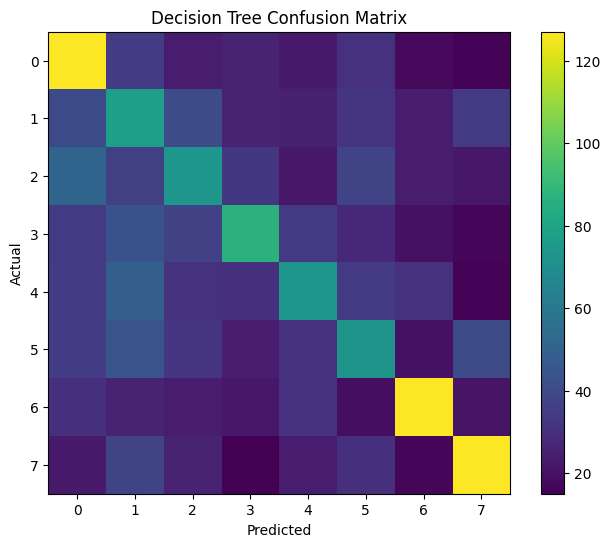

In [29]:
plt.figure(figsize=(8,6))

plt.imshow(cm)

plt.colorbar()

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## Save Model Weight

In [30]:
joblib.dump(dt, "Decision_Tree_Model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


## Test Model on New Image

### Upload Cell

In [31]:
from google.colab import files

uploaded = files.upload()

Saving test-image.webp to test-image.webp


### Load Model

In [32]:
model = joblib.load("Decision_Tree_Model.pkl")

### Read Image

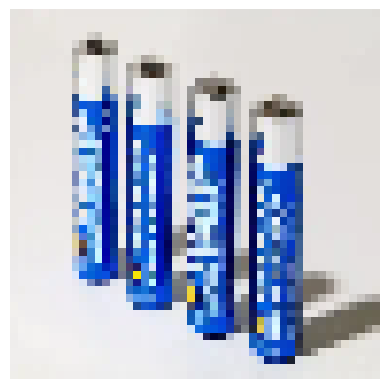

In [33]:
image_path = list(uploaded.keys())[0]

test_image = cv2.imread(image_path)

test_image = cv2.resize(test_image, (48,48))

plt.imshow(cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB))

plt.axis("off")

plt.show()

### Predict Image

In [34]:
test_image = test_image.flatten()

test_image = test_image.reshape(1,-1)

prediction = model.predict(test_image)

print("Predicted Class:", prediction[0])

Predicted Class: trash


## Confidence Score

In [35]:
probabilities = model.predict_proba(test_image)

confidence = np.max(probabilities)

print("Confidence:", confidence * 100, "%")

Confidence: 100.0 %
